---
title: Aperture front
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.19.1
  kernelspec:
    display_name: phd
    language: python
    name: phd
format:
  html:
    code-fold: true
keep-ipynb: true
---


In this document I discuss about the
definition and evolution of aperture front with time.
Table of parameter values:

| Property | Value |
| --- | --- |
| Fracture length, $L$ | 100 m |
| Normal stiffness, $k_n$ | 50 GPa/m |
| Initial aperture, $w_i$ | 0.1 mm |
| Viscosity, $\mu$ | $10^{-3}$ Pa·s |
| Applied injection rate, $q_0$ | $10^{-5}$ m$^2$/s |
| Young’s modulus, $E$ | 60 GPa |
| Poisson’s ratio, $\nu$ | 0.25 |

I consider two cases of injection rate.

1. Low injection rate ($q_0 = 10^{-6}~\mathrm{m^2/s}$) -> **Rigid case**
2. High injection rate ($q_0 = 10^{-3}~\mathrm{m^2/s}$) -> **Soft case**

Import modules

In [1]:
from pathlib import Path
from typing import cast

import h5py
import matplotlib.pyplot as plt
import numpy as np

from mysolvers.exact_solutions import solve_linear_diffusion_const_flux

plt.style.use(["seaborn-v0_8-colorblind", "seaborn-v0_8-notebook"])

my package loaded


Functions

In [2]:
def read_run(filepath: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict]:
    with h5py.File(str(filepath), "r") as f:
        # x_sc = cast(h5py.Dataset, f["coordinates/x_subcontacts"])[:]
        x_vert = cast(h5py.Dataset, f["coordinates/x_vertices"])[:]
        t = cast(h5py.Dataset, f["coordinates/t"])[:]
        # sn_tx = cast(h5py.Dataset, f["fields/stress_normal"])[:]
        # p_tx = cast(h5py.Dataset, f["fields/fluid_pressure"])[:]
        w_tx = cast(h5py.Dataset, f["fields/aperture"])[:]
        params = {
            k: cast(h5py.Dataset, f[f"parameters/{k}"])[()]
            for k in cast(h5py.Group, f["parameters"]).keys()
        }
    return t, x_vert, w_tx, params


def find_front(
    x: np.ndarray, t: np.ndarray, w_tx: np.ndarray, w_front: np.ndarray | np.floating
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    assert np.array_equal(x, np.sort(x)), "x array must be sorted"
    # identify valid timesteps (crossing or front exists),
    # the inequality works for both a constant
    # and time-dependent front position due to [:, None] (transpose)
    w_front_arr = np.asarray(w_front)
    if w_front_arr.ndim == 0:
        w_front_arr = np.full(len(t), w_front_arr)
    below = w_tx < w_front_arr[:, None]
    mask = np.any(below, axis=1) & np.any(~below, axis=1)
    # apply mask
    below_valid = below[mask]
    w_valid = w_tx[mask]
    t_front = t[mask]
    # find first index where it goes from >= w_front
    # to < w_front (first index of True element)
    # detect crossings without edge cases
    cross = (~below_valid[:, :-1]) & (below_valid[:, 1:])
    cross_ind = np.argmax(cross, axis=1) + 1
    # indices for interpolation
    i_left = cross_ind - 1
    i_right = cross_ind
    # gather values
    x_left = x[i_left]
    x_right = x[i_right]
    # for each time step, grab the value at its specific column
    w_left = w_valid[np.arange(len(w_valid)), i_left]
    w_right = w_valid[np.arange(len(w_valid)), i_right]
    # linear interpolation:
    # x_f = x_left + (w_front - w_left) * (x_right - x_left) / (w_right - w_left)
    denom = w_right - w_left
    # avoid division by zero (flat segment edge case)
    denom = np.where(denom == 0, np.nan, denom)
    slope = (x_right - x_left) / denom
    x_front = x_left + (w_front_arr[mask] - w_left) * slope
    return t_front, x_front, mask

## Rigid case

Import results:

In [3]:
result_dir = Path.cwd().parent / "results" / "3dec" / "runs"
fp = result_dir / "run-q-1e-06.hdf5"
t, x_vert, w_tx, params = read_run(fp)

M = params["k_n"] / (12 * params["mu"])
D = M * params["w_i"] ** 3

# sort once
sort_ind = np.argsort(x_vert)
x_vert_sorted = x_vert[sort_ind]
w_tx_sorted = w_tx[:, sort_ind]

### Constant aperture front definition

Defining the aperture front as 1% increase
from the initial aperture $w_f = w_i (1 + 0.01)$
where $w_f$ is the aperture front and $w_i$ is initial aperture.
I use a simple function *find_front*
that searches the position where fracture
reaches $w_f$ at each time step of 3DEC simulation.

In [4]:
# define front threshold (constant)
w_front = params["w_i"] * (1 + 0.01)

t_front, x_front, mask_front = find_front(x_vert_sorted, t, w_tx_sorted, w_front)

Plotting the aperture profiles together with the front positions

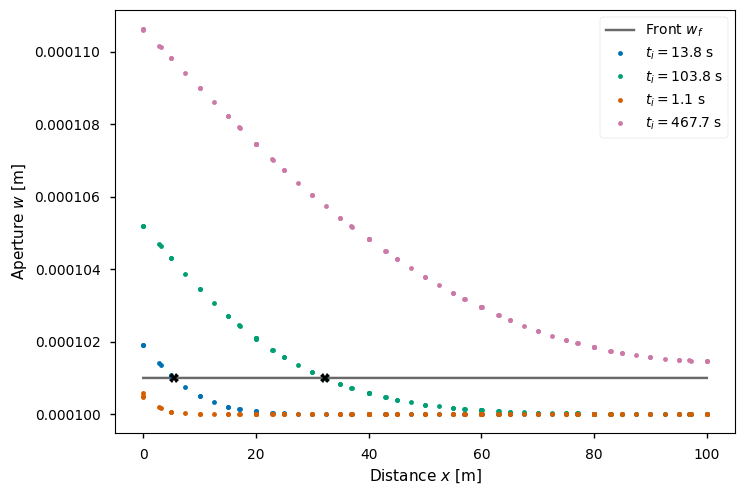

In [5]:
# Ensure array-like behavior
is_array = isinstance(w_front, np.ndarray)

plt.figure()
# --- Front line ---
if is_array:
    w_front_vals = w_front[mask_front]
else:
    w_front_vals = np.full_like(x_front, w_front)
plt.plot(
    x_front,
    w_front_vals,
    color="dimgray",
    label="Front $w_f$"
)
for i in [100, 1000]:
    plt.plot(
        x_vert_sorted,
        w_tx_sorted[mask_front][i],
        ".",
        label=f"$t_i={t_front[i]:.1f}$ s",
    )
    plt.plot(
        x_front[i],
        w_front_vals[i],
        marker="X",
        color="black"
    )
for i in [10, -1]:
    plt.plot(
        x_vert_sorted,
        w_tx_sorted[i],
        ".",
        label=f"$t_i={t[i]:.1f}$ s"
    )
plt.xlabel("Distance $x$ [m]")
plt.ylabel("Aperture $w$ [m]")
plt.legend()
plt.show()

### Analytical similarity solution

The exact similarity solution of linear diffusion (rigid case)
with constant flow rate boundary condition is
$$ \theta(\zeta) = \frac{2}{\sqrt{\pi}} \, e^{-\frac{\zeta^2}{4}}- \zeta \, \operatorname{erfc}\left(\frac{\zeta}{2}\right)$$
where $\theta$ and $\zeta$ are the dimensionless aperture
and distance:
$$\theta = \frac{w}{\sqrt{q_0^2 t / a}} \qquad \zeta = \frac{x}{\sqrt{Dt}}$$

In [6]:
zeta_analytical = np.linspace(0, 10, 100)
theta_analytical = solve_linear_diffusion_const_flux(zeta_analytical)

### Comparison with analytical solution

3DEC solutions for agree with analytical solution and all aperture
profiles collapse onto one curve. However the black cross mark
that indicates the aperture front positions does not
remain constant in the similarity space.

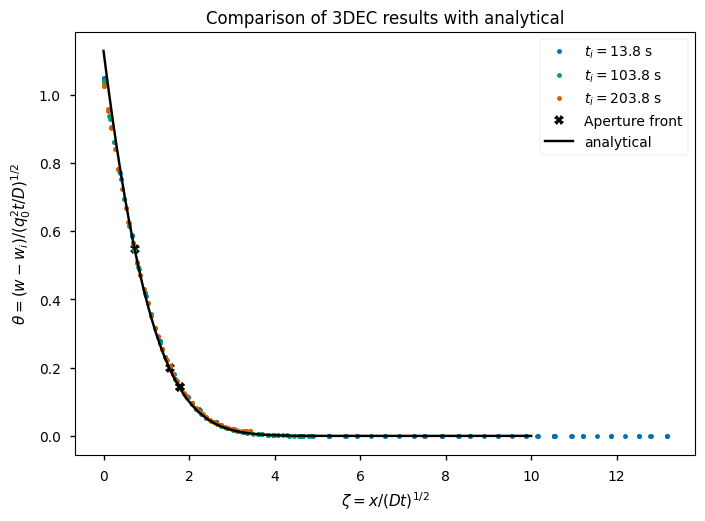

In [7]:
# %% compare analytical and 3dec in dimensionless space and mark the aperture point
plt.figure()
for i in [100, 1000, 2000]:
    w_front_i = w_front[mask_front][i] if is_array else w_front
    theta = (w_tx_sorted[mask_front][i] - params["w_i"]) / np.sqrt(
        params["q_0"] ** 2 * t_front[i] / D
    )
    zeta = x_vert_sorted / np.sqrt(D * t_front[i])
    plt.plot(zeta, theta, ".", label=f"$t_i=${t_front[i]:.1f} s")

    theta_front = (w_front_i - params["w_i"]) / np.sqrt(
        params["q_0"] ** 2 * t_front[i] / D
    )
    zeta_front = x_front[i] / np.sqrt(D * t_front[i])
    plt.plot(zeta_front, theta_front, "kX")

plt.plot(zeta_front, theta_front, "kX", label='Aperture front')

plt.plot(zeta_analytical, theta_analytical, "k", label="analytical")
plt.xlabel(r"$\zeta = x/(D t)^{1/2}$")
plt.ylabel(r"$\theta = (w-w_i)/(q_0^2 t/ D)^{1/2}$")
plt.legend()
plt.title('Comparison of 3DEC results with analytical')
plt.show()

### Distance-time plot

Although aperture profiles obtained from 3DEC agreed with exact solution,
the distance time plot of aperture front does not follow the analytical prediction.

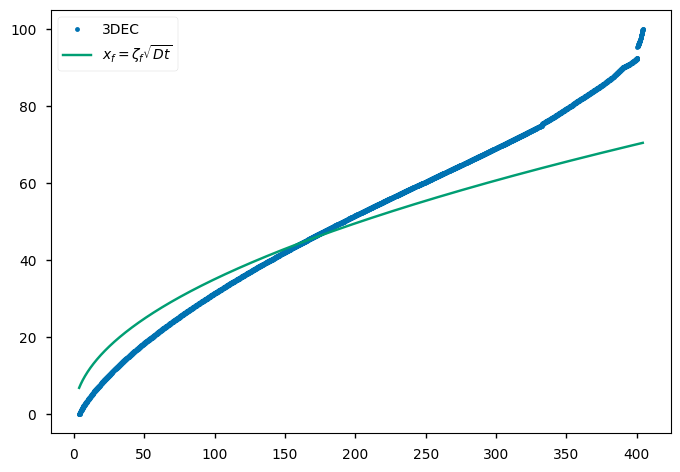

In [8]:
zeta_front = np.mean(x_front / np.sqrt(D * t_front))
x_front_analytical = zeta_front * np.sqrt(D * t_front)

# %% plotting
plt.figure()
plt.plot(t_front, x_front, ".", label="3DEC")
plt.plot(t_front, x_front_analytical, label=r"$x_f = \zeta_f \sqrt{D t}$")
plt.legend()
plt.show()

The mismatch between analytical prediction and 3dec solution is probably
due to the aperture front definition. Since we defined aperture at front $w_f$
to be 1% increase from initial value, it stays constant.
Hence, the dimensionless aperture
at front $$ \theta_f = (w_f - w_i)/ \sqrt{q_0^2 t / a} $$ changes with time. The following
plot demonstrates this.

In [9]:
theta_front = (np.full(t_front.shape, w_front) - params["w_i"]) / np.sqrt(
        params["q_0"] ** 2 * t_front / D
    )

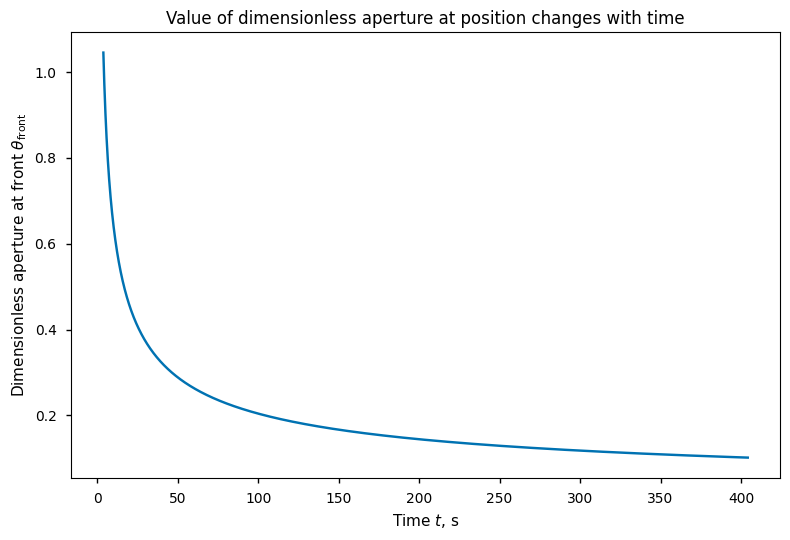

In [10]:
plt.figure()
plt.plot(t_front, theta_front)
plt.xlabel(r"Time $t$, s")
plt.ylabel(r"Dimensionless aperture at front $\theta_{\mathrm{front}}$")
plt.title("Value of dimensionless aperture at position changes with time")
plt.tight_layout()
plt.show()

### Self-similar aperture front definition

Since previous constant aperture front definition is not self-similar,
If I define the aperture front to be constant in dimensionless space.
, then the aperture at front is $w_f = \theta_f \, q_0 \sqrt{ t / a}$ and changes
with time. Let $\theta_f = 0.1$.

In [11]:
theta_front = 0.1
w_front = np.sqrt(params["q_0"] ** 2 * t / D) * theta_front + params["w_i"]
t_front, x_front, mask_front = find_front(x_vert_sorted, t, w_tx_sorted, w_front)

The figure below shows that with the new aperture front definition,
the aperture at front changes with time.

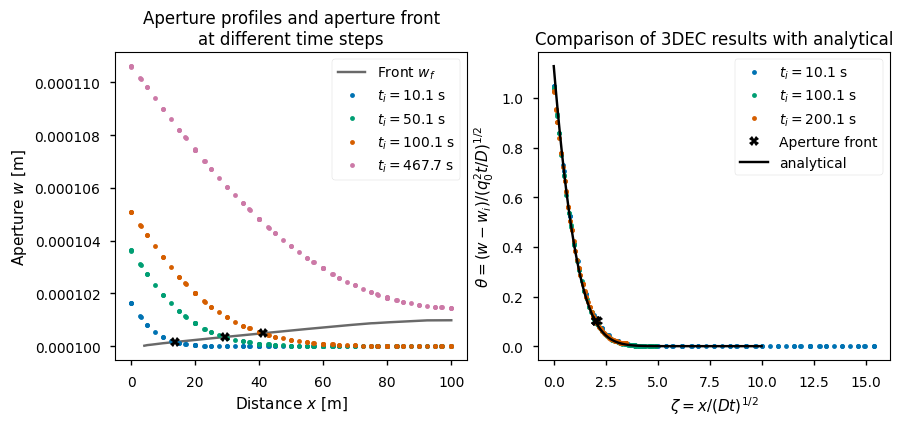

In [12]:
is_array = isinstance(w_front, np.ndarray)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))
# --- Front line ---
if is_array:
    w_front_vals = w_front[mask_front]
else:
    w_front_vals = np.full_like(x_front, w_front)
ax1.plot(
    x_front,
    w_front_vals,
    color="dimgray",
    label="Front $w_f$"
)
for i in [100, 500, 1000]:
    ax1.plot(
        x_vert_sorted,
        w_tx_sorted[mask_front][i],
        ".",
        label=f"$t_i={t_front[i]:.1f}$ s",
    )
    ax1.plot(
        x_front[i],
        w_front_vals[i],
        marker="X",
        color="black"
    )
for i in [-1]:
    ax1.plot(
        x_vert_sorted,
        w_tx_sorted[i],
        ".",
        label=f"$t_i={t[i]:.1f}$ s"
    )
ax1.set_xlabel("Distance $x$ [m]")
ax1.set_ylabel("Aperture $w$ [m]")
ax1.legend()
ax1.set_title('''Aperture profiles and aperture front
at different time steps''')

for i in [100, 1000, 2000]:
    w_front_i = w_front[mask_front][i] if is_array else w_front
    theta = (w_tx_sorted[mask_front][i] - params["w_i"]) / np.sqrt(
        params["q_0"] ** 2 * t_front[i] / D
    )
    zeta = x_vert_sorted / np.sqrt(D * t_front[i])
    ax2.plot(zeta, theta, ".", label=f"$t_i=${t_front[i]:.1f} s")

    theta_front = (w_front_i - params["w_i"]) / np.sqrt(
        params["q_0"] ** 2 * t_front[i] / D
    )
    zeta_front = x_front[i] / np.sqrt(D * t_front[i])
    ax2.plot(zeta_front, theta_front, "kX")
ax2.plot(zeta_front, theta_front, "kX", label='Aperture front')

ax2.plot(zeta_analytical, theta_analytical, "k", label="analytical")
ax2.set_xlabel(r"$\zeta = x/(D t)^{1/2}$")
ax2.set_ylabel(r"$\theta = (w-w_i)/(q_0^2 t/ D)^{1/2}$")
ax2.legend()
ax2.set_title('Comparison of 3DEC results with analytical')

plt.show()

Now using the self-similar aperture front definition,
the 3DEC results align with the analytical prediction.
Aperture front position scales with square root of time.

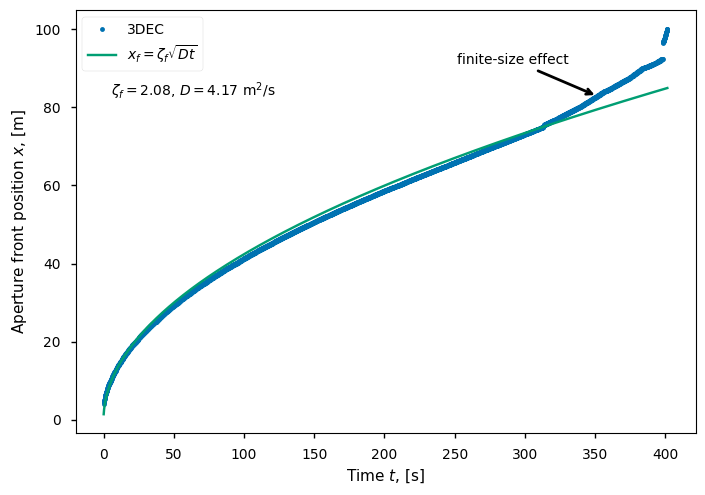

In [13]:
zeta_front = np.mean(x_front / np.sqrt(D * t_front))
x_front_analytical = zeta_front * np.sqrt(D * t_front)

# %% plotting
plt.figure()
plt.plot(t_front, x_front, ".", label="3DEC")
plt.plot(t_front, x_front_analytical, label=r"$x_f = \zeta_f \sqrt{D t}$")
plt.text(t_front[50], x_front[-500], fr'$\zeta_f={zeta_front:.2f}$, $D={D:.2f}~\mathrm{{m^2/s}}$')
plt.annotate(text='finite-size effect', xy=(t_front[-500], x_front[-500]), 
             xytext=(t_front[-1500], x_front[-100]),
             arrowprops=dict(arrowstyle="->", lw=2)
             )
plt.xlabel('Time $t$, [s]')
plt.ylabel('Aperture front position $x$, [m]')
plt.legend()
plt.show()

## Soft case